## Loading Necessary Dependencies

Let's import the libraries that we are going to use for data manipulation, visualization, training the model, etc.
We are going to train the LSTM using PyTorch library.

In [0]:
!pip install statsmodels --upgrade

     |████████████████████████████████| 8.7MB 2.7MB/s 
  Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2


In [0]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline 

##### IF you use light theme ,dont run this 
plt.rcParams[
    "figure.facecolor"
] = "w"  # force white background on plots when using dark mode in JupyterLab

 ## Load data


##### (a) the real data for Germany or Berlin

In [0]:
## USE RKI Cases and death  report

# read the data
deadth_RKI_report = pd.read_csv("https://raw.githubusercontent.com/jgehrcke/covid-19-germany-gae/master/deaths-rki-by-state.csv"
,index_col='time_iso8601',parse_dates=True, header=0)
case_RKI_report = pd.read_csv("https://raw.githubusercontent.com/jgehrcke/covid-19-germany-gae/master/cases-rki-by-state.csv"
,index_col='time_iso8601',parse_dates=True, header=0)

##### (b) from one of your SIR scenarios

In [0]:
df_B = pd.read_csv('data_B.csv')
df_B = df_B.iloc[:,1:]

##### (c) from one of your agent-based scenarios

In [0]:
df_C = pd.read_csv('data_C.csv')
df_C = df_C[df_C['Metric'] == "Infected" ]

df_C[["Avg", "Max"]]= df_C[["Avg", "Max"]].multiply(200) # multiply by population 

In [0]:
df_C[["Avg", "Max"]] = df_C[["Avg", "Max"]].astype(int)

## Prepare Training /Testing set

(a)
 For the real data, use data for 01.03.2020-20.04.2020 for training and then predict 21.4.-30.04.2020.

In [0]:
df_A_Train = case_RKI_report.loc['2020-03-01':'2020-04-20']
df_A_Test = case_RKI_report.loc['2020-04-21':'2020-04-30']

(b) 
From SEIR model

In [0]:
df_B_Train = df_B[0:len(df_B)-10]
df_B_Test = df_B[len(df_B)-10:]

(c)
From Agent Based - use avg number or max

In [0]:
df_C 

## Fitting 

In [0]:
import seaborn as sns
import statsmodels.api as sm  
from statsmodels.tsa.stattools import acf  
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.seasonal import seasonal_decompose

### (a)

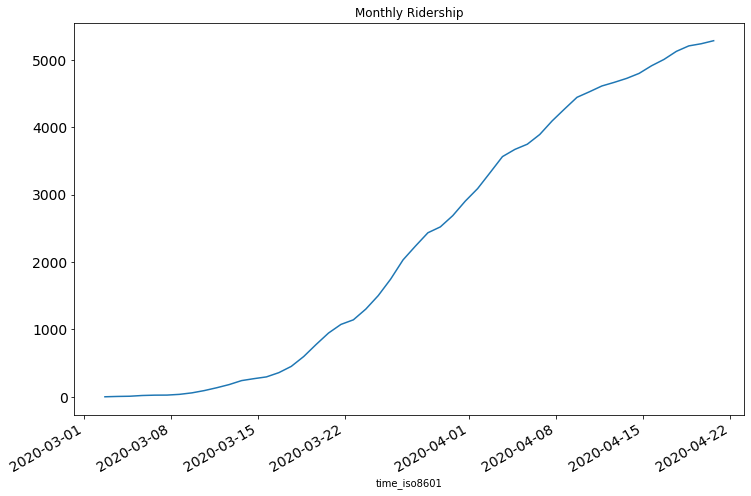

In [0]:
df_A_Train['DE-BE'].plot(figsize=(12,8), title= 'Monthly Ridership', fontsize=14)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: FutureWarning: the 'freq'' keyword is deprecated, use 'period' instead
  """Entry point for launching an IPython kernel.


<Figure size 432x288 with 0 Axes>

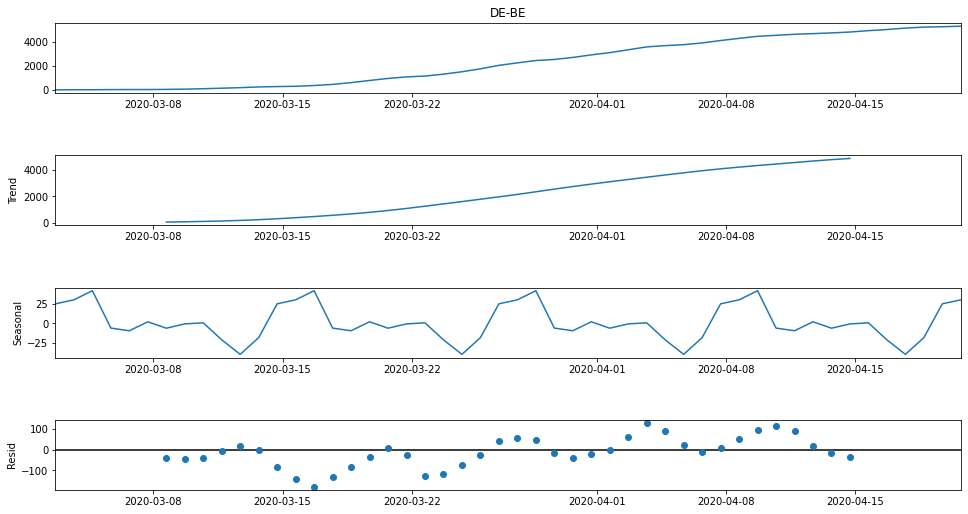

In [0]:
decomposition = seasonal_decompose(df_A_Train['DE-BE'], freq=12)  
fig = plt.figure()  
fig = decomposition.plot()  
fig.set_size_inches(15, 8)

Stationarize the data

In [0]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(2).mean()
    rolstd =timeseries.rolling(2).std()
    #Plot rolling statistics:
    plt.figure(figsize=(12,8))

    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
   
    plt.show()
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

In [0]:
df_A_Train['DE-BE'] = pd.to_numeric(df_A_Train['DE-BE'], errors='coerce')

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


This is not stationary because : 
 mean is increasing even though the std is small.

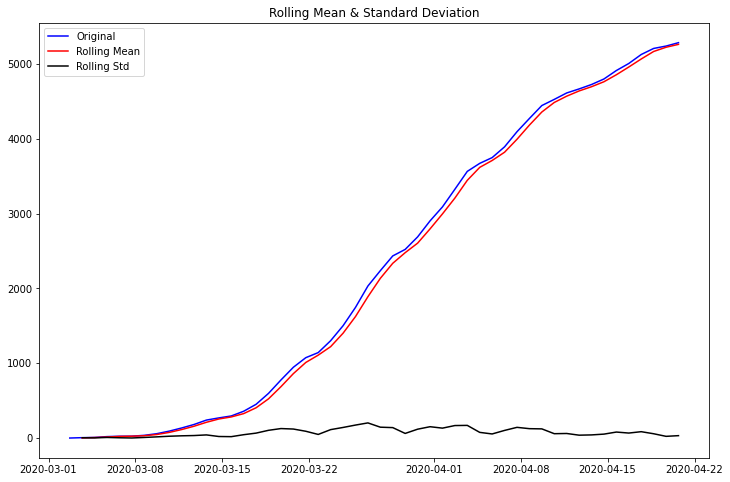

Results of Dickey-Fuller Test:
Test Statistic                 -3.008683
p-value                         0.034091
#Lags Used                      7.000000
Number of Observations Used    42.000000
Critical Value (1%)            -3.596636
Critical Value (5%)            -2.933297
Critical Value (10%)           -2.604991
dtype: float64


In [0]:
test_stationarity(df_A_Train['DE-BE'])

 Reduce the trend using transformation

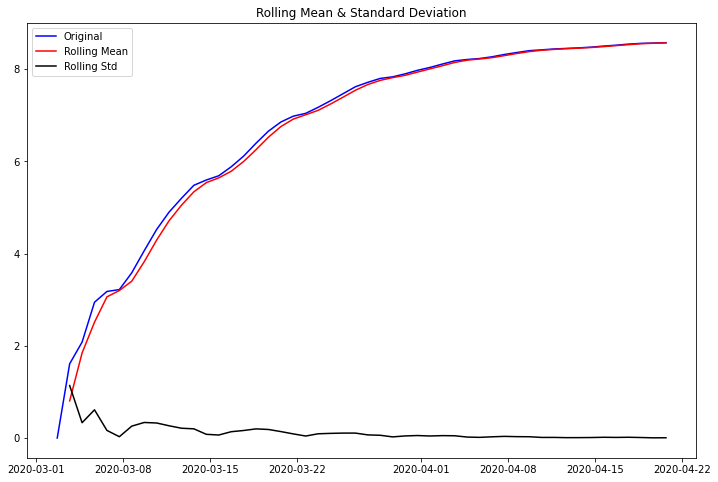

Results of Dickey-Fuller Test:
Test Statistic                 -4.530152
p-value                         0.000173
#Lags Used                      7.000000
Number of Observations Used    42.000000
Critical Value (1%)            -3.596636
Critical Value (5%)            -2.933297
Critical Value (10%)           -2.604991
dtype: float64


In [0]:
#df.DE_BE_log = np.log(df_A_Train['DE-BE'])
DE_BE_log= df_A_Train['DE-BE'].apply(lambda x:  np.log(x) if x!= 0 else  0  )  
test_stationarity(DE_BE_log)

#### AR MODEL

In [0]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn import preprocessing
from sklearn import metrics
from sklearn.model_selection import train_test_split
from statsmodels.tsa.ar_model import AutoReg
import math

In [0]:
A_Train = df_A_Train['DE-BE']
A_Test = df_A_Test['DE-BE']

In [0]:
len(predictions)

10

In [0]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt
from datetime import datetime

model = AutoReg(A_Train.values, lags=16) #
model_fit = model.fit()
#print('Coefficients: %s' % model_fit.params)
# make predictions
train_pred = model_fit.predict(start=0, end=len(A_Train), dynamic=False)
predictions = model_fit.predict(start=len(A_Train), end=len(A_Train)+len(A_Test)-1, dynamic=False)

df_pre = pd.DataFrame()
df_pre['date'] = pd.to_datetime(A_Test.index)
df_pre.set_index('date', inplace=True)
df_pre['y'] = predictions

In [0]:
#print('Train Mean Absolute Error:', mean_absolute_error(A_Train.values, predictions.iloc[0:50,-1]))
#print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(A_Train.values, predictions.iloc[0:50,-1])))
print('Test Mean Absolute Error:', mean_absolute_error(A_Test.values, predictions))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(A_Test.values, predictions)))

Test Mean Absolute Error: 97.88461879306541
Test Root Mean Squared Error: 117.40765365609617


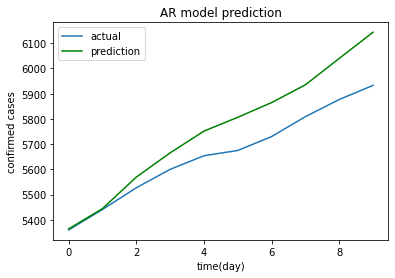

In [0]:
plt.plot(A_Test.values, label="actual")
plt.plot(df_pre.values, label="prediction", color='green')

plt.title('AR model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper left')
plt.show()

#### ARAM

In [0]:
import statsmodels.api as sm
res = sm.tsa.arma_order_select_ic(A_Train, ic = ['aic','bic'], trend = 'nc')
res.aic_min_order
res.bic_min_order

/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:548: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:548: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/tsatools.py:689: RuntimeWarning: overflow encountered in exp
  newparams = ((1-np.exp(-params))/(1+np.exp(-params))).copy()
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/tsatools.py:689: RuntimeWarning: invalid value encountered in true_divide
  newparams = ((1-np.exp(-params))/(1+np.exp(-params))).copy()
/usr/local/lib/python3.6/dist-packages/sta

(2, 1)

In [0]:
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.stattools import adfuller, arma_order_select_ic

model = ARMA(A_Train.values, order = (2,0)) #
model_fit = model.fit()
predictions = model_fit.predict(start=len(A_Train), end=len(A_Train)+len(A_Test)-1, dynamic=False)
#for i in range(len(predictions)):
#	print('predicted=%f, expected=%f' % (predictions[i], A_Train[i]))
rmse = sqrt(mean_squared_error(A_Test.values, predictions))
print('Test RMSE: %.3f' % rmse)

df_pre = pd.DataFrame()
df_pre['date'] = pd.to_datetime(df_A_Test.index)
df_pre.set_index('date', inplace=True)
df_pre['y'] = predictions

Test RMSE: 159.743


/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:548: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)


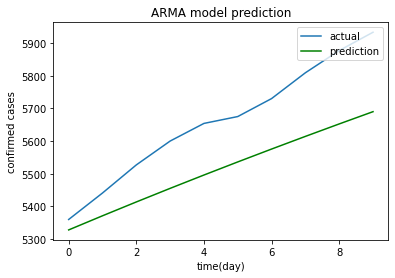

In [0]:
plt.plot(A_Test.values, label="actual")
plt.plot(df_pre.values, label="prediction", color='green')

plt.title('ARMA model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()

### (b)

#### AR MODEL

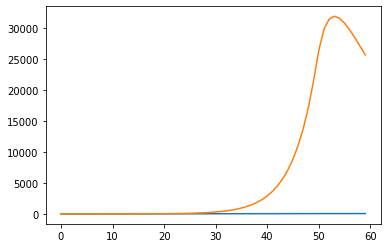

In [0]:
plt.plot(df_B)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


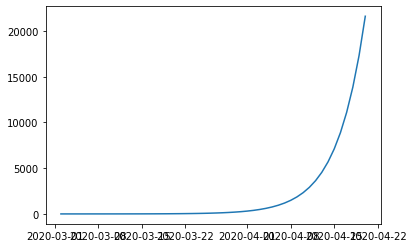

In [0]:
B_Train = df_B_Train
B_Test = df_B_Test

B_Train['Time'] = pd.date_range('2020-03-02', periods=50, freq='D')
B_Test['Time'] = pd.date_range('2020-04-21', periods=10, freq='D')
B_Train.set_index('Time', inplace=True)
B_Test.set_index('Time', inplace=True)
plt.plot(B_Train)

In [0]:
from sklearn.metrics import mean_squared_error
from math import sqrt
from datetime import datetime

model = AutoReg(B_Train.values, lags=16) #
model_fit = model.fit()
print('Coefficients: %s' % model_fit.params)
# make predictions
predictions = model_fit.predict(start=len(B_Train), end=len(B_Train)+len(B_Test)-1, dynamic=False)

df_pre = pd.DataFrame()
df_pre['date'] = pd.date_range('2020-04-21', periods=10, freq='D')
df_pre.set_index('date', inplace=True)
df_pre['y'] = predictions

Coefficients: [-1.42435961  1.33027559  1.61970418 -1.3156443  -0.99373542  0.74296498
 -0.06441769 -0.64822835  0.2076048  -0.34587382 -0.22980905 -0.62467386
  0.01571529  0.59973286 -0.30791182 -0.97222946 -0.29457628]


In [0]:
print('Test Mean Absolute Error:', mean_absolute_error(B_Test.values, predictions))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(B_Test.values, predictions)))

Test Mean Absolute Error: 53485.09937893386
Test Root Mean Squared Error: 71618.49832567031


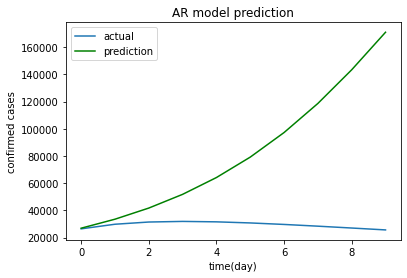

In [0]:

plt.plot(B_Test.values, label="actual")
plt.plot(df_pre.values, label="prediction", color='green')

plt.title('AR model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper left')
plt.show()

#### ARAM

In [0]:
import statsmodels.api as sm
res = sm.tsa.arma_order_select_ic(B_Train.values, ic = ['aic','bic'], trend = 'c')
res.aic_min_order

/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:548: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:548: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/tsatools.py:672: RuntimeWarning: divide by zero encountered in arctanh
  invarcoefs = 2*np.arctanh(params)
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/tsatools.py:689: RuntimeWarning: overflow encountered in exp
  newparams = ((1-np.exp(-params))/(1+np.exp(-params))).copy()
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/tsatools.py:689: 

(4, 1)

In [0]:
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.stattools import adfuller, arma_order_select_ic

model = ARMA(B_Train.values, order = (1,0)) #
model_fit = model.fit()
predictions = model_fit.predict(start=len(B_Train), end=len(B_Train)+len(B_Test)-1, dynamic=False)
#for i in range(len(predictions)):
#	print('predicted=%f, expected=%f' % (predictions[i], B_Train.values[i]))
rmse = sqrt(mean_squared_error(B_Test.values, predictions))
print('Test RMSE: %.3f' % rmse)

df_pre = pd.DataFrame()
df_pre['date'] = pd.date_range('2020-04-21', periods=10, freq='D')
df_pre.set_index('date', inplace=True)
df_pre['y'] = predictions

Test RMSE: 8264.271


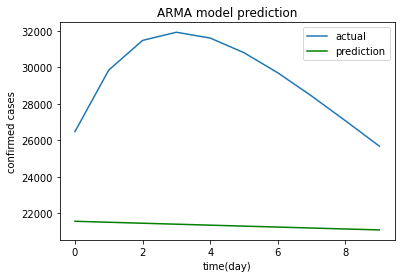

In [0]:
plt.plot(B_Test.values, label="actual")
plt.plot(df_pre.values, label="prediction", color='green')

plt.title('ARMA model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()

In [0]:
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.stattools import adfuller, arma_order_select_ic

model = ARIMA(B_Train.values, order = (1,0,0)) #
model_fit = model.fit()
predictions = model_fit.predict(start=len(B_Train), end=len(B_Train)+len(B_Test)-1, dynamic=False)
for i in range(len(predictions)):
	print('predicted=%f, expected=%f' % (predictions[i], B_Train.values[i]))
rmse = sqrt(mean_squared_error(B_Test.values, predictions))
print('Test RMSE: %.3f' % rmse)

df_pre = pd.DataFrame()
df_pre['date'] = pd.date_range('2020-04-21', periods=10, freq='D')
df_pre.set_index('date', inplace=True)
df_pre['y'] = predictions

### (c)

In [0]:
df_C

,Iteration,Metric,Min,Avg,Std,Max
1,0,Infected,0.020,5,0.006180,8
14,1,Infected,0.020,7,0.012093,13
27,2,Infected,0.020,10,0.017340,17
40,3,Infected,0.030,12,0.022665,23
53,4,Infected,0.035,15,0.027985,26
...,...,...,...,...,...,...
1236,95,Infected,0.000,13,0.077709,57
1249,96,Infected,0.000,14,0.078760,57
1262,97,Infected,0.000,13,0.075804,56
1275,98,Infected,0.000,13,0.074505,55


In [0]:
C_accumulate = df_C.Avg
C_accumulate.index = pd.date_range('2020-03-02', periods=100, freq='D')

C_Train = C_accumulate[:50]
C_Test = C_accumulate[50:60]

In [0]:
C_Test

2020-04-21    11
2020-04-22    10
2020-04-23     8
2020-04-24     7
2020-04-25     7
2020-04-26     7
2020-04-27     7
2020-04-28     7
2020-04-29     8
2020-04-30     8
Freq: D, Name: Avg, dtype: int64

#### AR MODEL

In [0]:
from sklearn.metrics import mean_squared_error
from math import sqrt
from datetime import datetime

model = AutoReg(C_Train.values, lags=16) #
model_fit = model.fit()
print('Coefficients: %s' % model_fit.params)
# make predictions
predictions = model_fit.predict(start=len(C_Train), end=len(C_Train)+len(C_Test)-1, dynamic=False)

df_pre = pd.DataFrame()
df_pre['date'] = pd.date_range('2020-04-21', periods=10, freq='D')
df_pre.set_index('date', inplace=True)
df_pre['y'] = predictions

Coefficients: [ 5.18994317e+00  1.41741259e+00 -2.48032075e-01 -1.01982602e-01
 -5.06141103e-01  6.02598475e-01 -4.08774536e-01 -4.77522396e-03
  5.50593058e-01 -3.28862478e-01 -2.20883058e-01  9.85497942e-03
  5.50800019e-01 -5.73233422e-01  2.79591284e-01  7.00658781e-02
 -2.05581494e-01]


In [0]:
print('Test Mean Absolute Error:', mean_absolute_error(C_Test.values, predictions))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(C_Test.values, predictions)))

Test Mean Absolute Error: 20.501192403867954
Test Root Mean Squared Error: 23.909035987322994


No handles with labels found to put in legend.


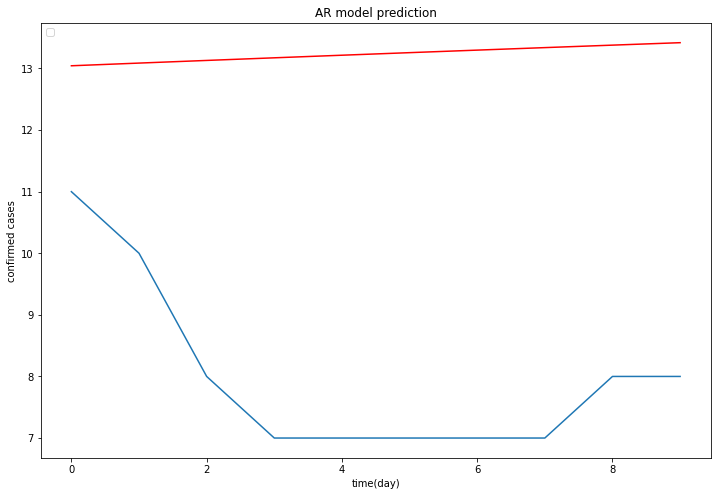

In [0]:
plt.figure(figsize=(12,8))
plt.plot(C_Test.values)
plt.plot(df_pre.values, color='red')

plt.title('AR model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper left')
plt.show()

#### ARAM

In [0]:
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.stattools import adfuller, arma_order_select_ic

model = ARMA(C_Train.values, order = (1,0)) #
model_fit = model.fit()
predictions = model_fit.predict(start=len(C_Train), end=len(C_Train)+len(C_Test)-1, dynamic=False)
#for i in range(len(predictions)):
#	print('predicted=%f, expected=%f' % (predictions[i], C_Train.values[i]))
rmse = sqrt(mean_squared_error(C_Test.values, predictions))
print('Test RMSE: %.3f' % rmse)

df_pre = pd.DataFrame()
df_pre['date'] = pd.date_range('2020-04-21', periods=10, freq='D')
df_pre.set_index('date', inplace=True)
df_pre['y'] = predictions

Test RMSE: 5.423


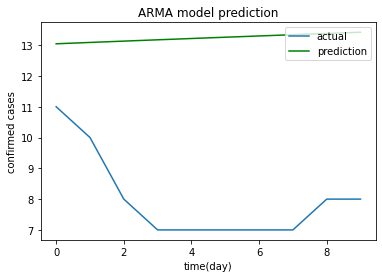

In [0]:
plt.plot(C_Test.values, label="actual")
plt.plot(df_pre.values, label="prediction", color='green')

plt.title('ARMA model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()